In [157]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [158]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [159]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [160]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [161]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (171145326723)>


In [162]:
ops.wipe()

# User-defined variables
massDen = 2.0
massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.001
fangle = 31.40 / 1.0
ptangle = 26.50 / 1.0
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
deltaT = 0.010
numSteps = 1000
gamma = 0.500
period = 1
pi = math.pi
inclination = 0
unitWeightX = massDen * 9.81 * math.sin(inclination / 180.0 * pi)
unitWeightY = -massDen * 9.81 * math.cos(inclination / 180.0 * pi)
loadIncr = 1.0

# Model builder
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Define material
ops.nDMaterial('PressureDependMultiYield', 2, 2, massDen, G, B, fangle, 0.1, 80, 0.5,
           ptangle, 0.17, 0.4, 10, 0, 0.015, 1.0)

# Define nodes
ops.node(1, 0.0000 , 0.0000)
ops.node(2, 1.0000 , 0.0000)
ops.node(3, 0.5000 , 0.5000)
ops.node(4, 1.0000 , 1.0000)
ops.node(5, 0.0000 , 1.0000)

# Define element
ops.element('Tri31', 1, 1, 2, 3, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)
ops.element('Tri31', 2, 2, 4, 3, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)
ops.element('Tri31', 3, 3, 4, 5, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)
ops.element('Tri31', 4, 1, 3, 5, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)

In [163]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [164]:

#ops.element('quad', 1, 1, 2, 3, 4, 1.0, 'PlaneStrain', 2, press, 0.0, unitWeightX, unitWeightY)
#ops.element('SSPquadUP', 1, 1, 2, 3, 4, 2, 1.0, 2.2e6, 1.0) #1.0e-3, 1.0e-3, 0.7, 6.0e-5, 0.0, -9.81
# Initial elastic stage
ops.updateMaterialStage('-material', 2, '-stage', 0)

# Boundary conditions
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.equalDOF(4, 5, 1, 2)

# Gravity load application
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 30, 0)
ops.algorithm("KrylovNewton")
ops.constraints("Penalty", 1.e18, 1.e18)
ops.integrator("Newmark", 1.5, (1.5 + 0.5) ** 2 / 4)
ops.analysis("Transient")
ops.analyze(10, 5e3)

newBulk = G * 2 / 3
# --- switch the material to plastic ---
# switch material in Python

ops.parameter(1001, 'element', 1, "bulkModulus", '2')

# Switch to plastic stage
ops.updateMaterialStage('-material', 2, '-stage', 1)
ops.updateParameter(1001, newBulk) 

1001

In [165]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [166]:
# Apply pushover load

ops.setTime(0.0)
ops.wipeAnalysis()
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(4, 0.0, -1.0)
ops.load(5, 1.2, 0.0)

# Recorders
ops.recorder('Node', '-file', 'f2disp.out', '-time', '-node', *[1, 2, 3, 4], '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'f2acce.out', '-time', '-node', *[1, 2, 3, 4], '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2stress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2strain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2stress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'f2strain3.out', '-dT', 0.01, 'material', 3, 'strain')

# Static analysis for pushover
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 30, 0)
ops.algorithm("KrylovNewton")
ops.constraints("Penalty", 1.e18, 1.e18)
ops.integrator("Newmark", 1.5, (1.5 + 0.5) ** 2 / 4)
ops.analysis('VariableTransient') #VariableTransient

ODB = opst.post.CreateODB(
    odb_tag="PDMY05",
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)


startT = tt.time()
for _ in range(2000):
    ops.analyze(1, deltaT, deltaT / 100, deltaT, 10)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)
endT = tt.time()

ops.wipe()

OPSTOOL ::  All responses data with _odb_tag = PDMY05 saved in .opstool.output/RespStepData-PDMY05.nc!

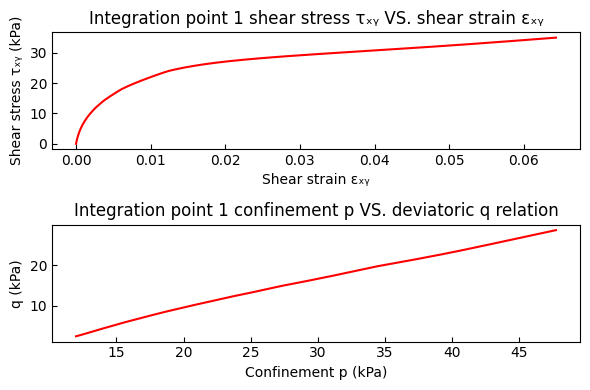

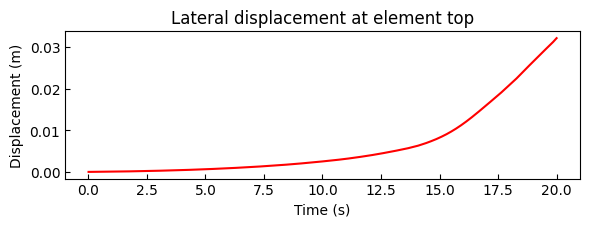

In [167]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('f2acce.out')
d1 = np.loadtxt('f2disp.out')
s1 = np.loadtxt('f2stress1.out')
e1 = np.loadtxt('f2strain1.out')

# Approximate MATLAB paperposition as figure size
figsize = (6, 4)

def compute_p_q(stress):
    """Compute confinement p (po) and deviatoric stress q (qo)."""
    po = np.mean(stress[:, 1:4], axis=1)
    qo = []
    for i in range(len(stress)):
        q = ((stress[i,1] - stress[i,2])**2 +
             (stress[i,2] - stress[i,3])**2 +
             (stress[i,1] - stress[i,3])**2 +
             6.0 * stress[i,4]**2)
        q = np.sign(stress[i,4]) * (1/3.0) * np.sqrt(q)
        qo.append(q)
    return po, np.array(qo)

# --- Integration Point 1 ---
po1, qo1 = compute_p_q(s1)

plt.figure(1, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(e1[:,3], s1[:,4], 'r') #CHANGE THE DATA FRAME LOCATION OF STRAIN
plt.title('Integration point 1 shear stress τₓᵧ VS. shear strain εₓᵧ')
plt.xlabel('Shear strain εₓᵧ')
plt.ylabel('Shear stress τₓᵧ (kPa)')

plt.subplot(2,1,2)
plt.plot(-po1, qo1, 'r')
plt.title('Integration point 1 confinement p VS. deviatoric q relation')
plt.xlabel('Confinement p (kPa)')
plt.ylabel('q (kPa)')

plt.tight_layout()
plt.savefig('SS_PQ1.jpg')
plt.show()

# --- Displacement ---
plt.figure(2, figsize=figsize)
plt.clf()
plt.subplot(2,1,1)
plt.plot(d1[:,0], d1[:,5], 'r')  # MATLAB col 6 → Python col index 5
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')

plt.tight_layout()
plt.savefig('D.jpg')
plt.show()


In [168]:
ele_resp = opst.post.get_element_responses(odb_tag="PDMY05", ele_type="Plane")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-PDMY05.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 160kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 96kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 200kB -8.409 ...
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 120kB 7.183e-...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 200kB 0.4444 ...
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 120kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 128kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 128kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 160kB -8.357 .....
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 160kB 3.084e-06...


In [169]:
ele_resp.data_vars

Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 160kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 96kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 200kB -8.409 ...
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 120kB 7.183e-...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 200kB 0.4444 ...
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 120kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 128kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 128kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 160kB -8.357 .....
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 160kB 3.084e-06...

In [1]:
print(ele_resp.stressDOFs.data)
print(ele_resp.strainDOFs.data)
print(ele_resp.measures.data)

NameError: name 'ele_resp' is not defined

In [ ]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)

In [ ]:
s11 = sigma11.sel(GaussPoints=1)
s22 = sigma22.sel(GaussPoints=1)
s33 = sigma33.sel(GaussPoints=1)
s12 = sigma12.sel(GaussPoints=1)

In [ ]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 2001, GaussPoints: 1)> Size: 8kB
array([[ 2.422346 ],
       [ 2.4247956],
       [ 2.4296346],
       ...,
       [28.608768 ],
       [28.628355 ],
       [28.647987 ]], shape=(2001, 1), dtype=float32)
Coordinates:
  * time         (time) float32 8kB 0.0 0.01 0.02 0.03 ... 19.98 19.99 20.0
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 8B 1
    stressDOFs   <U7 28B 'sigma12'


In [ ]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

In [ ]:
ep11 = eps11.sel(GaussPoints=1)
ep22 = eps22.sel(GaussPoints=1)
ep12 = eps12.sel(GaussPoints=1)
print(ep11)

<xarray.DataArray 'Strains' (time: 2001)> Size: 8kB
array([8.8757141e-18, 8.8759970e-18, 8.8771419e-18, ..., 3.8154311e-17,
       3.8177343e-17, 3.8200415e-17], shape=(2001,), dtype=float32)
Coordinates:
  * time         (time) float32 8kB 0.0 0.01 0.02 0.03 ... 19.98 19.99 20.0
    eleTags      int64 8B 1
    GaussPoints  int64 8B 1
    strainDOFs   <U5 20B 'eps11'


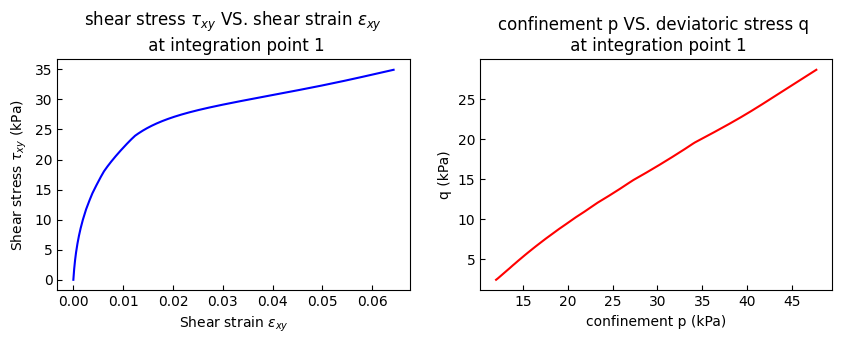

In [ ]:
eps12_ele1_1 = eps12.sel(GaussPoints=1).values
sigma12_ele1_1 = sigma12.sel(GaussPoints=1).values
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [ ]:
node_resp = opst.post.get_nodal_responses(odb_tag="PDMY05")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-PDMY05.nc ...

<xarray.Dataset> Size: 1MB
Dimensions:             (time: 2001, nodeTags: 5, DOFs: 6)
Coordinates:
  * time                (time) float32 8kB 0.0 0.01 0.02 ... 19.98 19.99 20.0
  * nodeTags            (nodeTags) int64 40B 1 2 3 4 5
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 240kB -4.438e-18 ... 0.0
    vel                 (time, nodeTags, DOFs) float32 240kB 9.614e-38 ... 0.0
    accel               (time, nodeTags, DOFs) float32 240kB 2.076e-41 ... 0.0
    reaction            (time, nodeTags, DOFs) float32 240kB 4.438 9.81 ... 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 240kB 4.438 9.81 ... 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 240kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 40kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Displacement in 

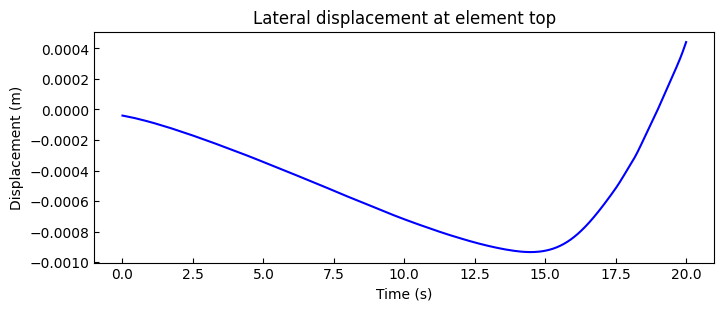

[-3.9966668e-05 -4.0156607e-05 -4.0530311e-05 ...  4.3033919e-04
  4.3574185e-04  4.4116951e-04]


In [ ]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UY")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UY")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 - disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()
print(disp3.values)

In [ ]:
from scipy.interpolate import interp1d


t = np.linspace(0, 20 * np.pi, int(20 * np.pi / (np.pi / 50)) + 1)
s = 2 * np.sin(t)
s = np.concatenate((s, np.zeros(3000)))
x_original = np.linspace(0, 40, len(s))
interp_func = interp1d(x_original, s, kind="linear", fill_value="extrapolate")
s1 = interp_func(times)

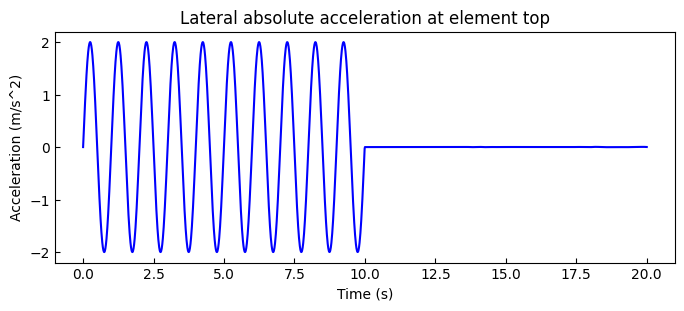

In [ ]:
acc3 = node_resp["accel"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, s1 + acc3, "b")
ax.set_title("Lateral absolute acceleration at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Acceleration (m/s^2)")
plt.show()

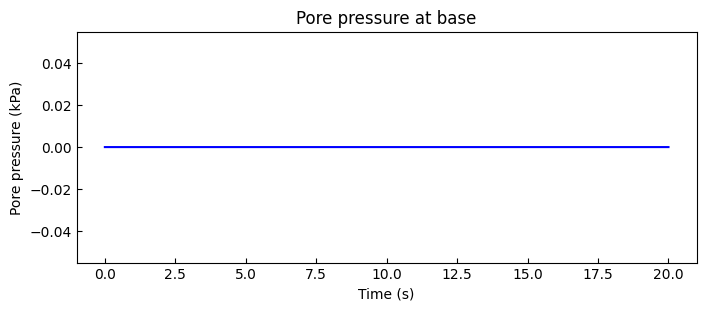

In [ ]:
p1 = node_resp["vel"].sel(nodeTags=1, DOFs="RZ")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.plot(times, p1, "b")
ax.set_title("Pore pressure at base")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pore pressure (kPa)")
plt.show()

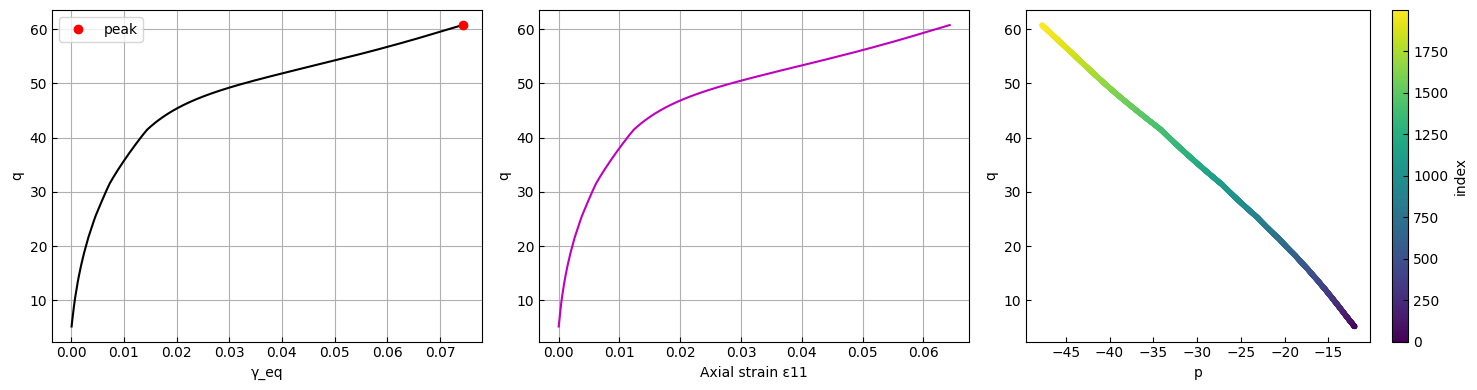

In [ ]:
"""
File: scripts/soil_backbone_plot.py

Now supports reading your .out stress and strain files (time + stress/strain values).
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

def load_stress_file(filename: str):
    data = np.loadtxt(filename)
    time = data[:, 0]
    s11 = data[:, 1]
    s22 = data[:, 2]
    s33 = data[:, 3]
    s12 = data[:, 4]
    return time, s11, s22, s33, s12

def load_strain_file(filename: str):
    data = np.loadtxt(filename)
    time = data[:, 0]
    e11 = data[:, 1]
    e22 = data[:, 2]
    e12 = data[:, 3]
    return time, e11, e22, e12

def trim_to_same_length(*arrays):
    arrays_np = [np.asarray(a) for a in arrays]
    min_len = min(len(a) for a in arrays_np)
    return [a[:min_len] for a in arrays_np]

def compute_p_q(s11, s22, s33, s12):
    s11, s22, s33, s12 = trim_to_same_length(s11, s22, s33, s12)
    p = (s11 + s22 + s33) / 3.0
    s1 = s11 - p
    s2 = s22 - p
    s3 = s33 - p
    s_dot_s = s1**2 + s2**2 + s3**2 + 2.0 * (s12**2)
    q = np.sqrt(1.5 * s_dot_s)
    return p, q

def compute_gamma_eq(e11, e22, e33, e12):
    e11, e22, e33, e12 = trim_to_same_length(e11, e22, e33, e12)
    eps_v = e11 + e22 + e33
    ed1 = e11 - eps_v / 3.0
    ed2 = e22 - eps_v / 3.0
    ed3 = e33 - eps_v / 3.0
    ed_dot_ed = ed1**2 + ed2**2 + ed3**2 + 2.0 * (e12**2)
    gamma_eq = np.sqrt(2.0/3.0 * ed_dot_ed)
    return eps_v, gamma_eq

def detect_peak_failure(q, gamma, drop_frac=0.1, lookahead=3):
    q = np.asarray(q)
    peak_idx = int(np.argmax(q))
    peak_q = q[peak_idx]
    thresh = (1.0 - drop_frac) * peak_q
    failure_idx = None
    for i in range(peak_idx + 1, len(q) - lookahead):
        if np.all(q[i:i+lookahead] < thresh):
            failure_idx = i
            break
    return {
        'peak_index': peak_idx,
        'peak_q': float(peak_q),
        'peak_gamma': float(gamma[peak_idx]) if len(gamma) > peak_idx else None,
        'failure_index': int(failure_idx) if failure_idx is not None else None,
        'failure_q': float(q[failure_idx]) if failure_idx is not None else None,
        'failure_gamma': float(gamma[failure_idx]) if (failure_idx is not None and len(gamma) > failure_idx) else None
    }

def plot_backbone(q, gamma, eps_axial=None, p=None, meta=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(gamma, q, '-k', lw=1.5)
    if meta:
        peak = meta.get('peak_index')
        failure = meta.get('failure_index')
        if peak is not None:
            axes[0].plot(gamma[peak], q[peak], 'ro', label='peak')
        if failure is not None:
            axes[0].plot(gamma[failure], q[failure], 'bx', label='failure')
        axes[0].legend()
    axes[0].set_xlabel('γ_eq')
    axes[0].set_ylabel('q')
    axes[0].grid(True)
    if eps_axial is not None:
        eps_axial, q_ax = trim_to_same_length(eps_axial, q)
        axes[1].plot(eps_axial, q_ax, '-m')
        axes[1].set_xlabel('Axial strain ε11')
        axes[1].set_ylabel('q')
        axes[1].grid(True)
    else:
        axes[1].axis('off')
    if p is not None:
        p, q_p = trim_to_same_length(p, q)
        sc = axes[2].scatter(p, q_p, c=np.arange(len(q_p)), cmap='viridis', s=8)
        axes[2].set_xlabel('p')
        axes[2].set_ylabel('q')
        plt.colorbar(sc, ax=axes[2], label='index')
    else:
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    stress_time, s11, s22, s33, s12 = load_stress_file('f2stress1.out')
    strain_time, e11, e22, e12 = load_strain_file('f2strain1.out')
    e33 = -(e11 + e22)
    p, q = compute_p_q(s11, s22, s33, s12)
    eps_v, gamma = compute_gamma_eq(e11, e22, e33, e12)
    meta = detect_peak_failure(q, gamma)
    plot_backbone(q, gamma, eps_axial=e12, p=p, meta=meta)
